# Circuit Verification

A circuit must use the gates and connections that a quantum device supports.
Transpilation makes those changes, but the compiled circuit should still perform
the intended operation. We first verify a circuit compiled for a hardware
target, then introduce a rotation-angle bug and ask how hardware noise changes
its agreement with the original circuit.

This extends the circuit comparison in {doc}`quickstart`. The four-qubit example
uses the standard YAQS installation and Matplotlib for plotting, without a
hardware account. Run the cells in order in a notebook; for a script, use the
entry-point guard in {doc}`simulator_initialization`.

## 1. Compile for hardware constraints

Our circuit entangles qubit 0 with every other qubit, then applies local
rotations. A device with a line of nearest-neighbor connections cannot execute
all three controlled-X gates directly. The transpiler must route the circuit and
express its rotations in the device's native gate set.

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.providers.fake_provider import GenericBackendV2

num_qubits = 4
original = QuantumCircuit(num_qubits)
original.h(0)
for site in range(1, num_qubits):
    original.cx(0, site)
for site in range(num_qubits):
    original.ry(0.3 * (site + 1), site)

connections = [[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2]]
backend = GenericBackendV2(
    num_qubits,
    basis_gates=["rz", "sx", "x", "cx"],
    coupling_map=connections,
    noise_info=False,
)
compiled = transpile(
    original,
    backend=backend,
    initial_layout=list(range(num_qubits)),
    optimization_level=1,
    seed_transpiler=7,
)

print("Original gates:", dict(original.count_ops()))
print("Compiled gates:", dict(compiled.count_ops()))

Original gates: {'ry': 4, 'cx': 3, 'h': 1}
Compiled gates: {'rz': 10, 'sx': 9, 'cx': 9}


`GenericBackendV2` supplies an **offline hardware target**, not measured device
data. To compile for a real device, pass that device's Qiskit backend instead.
The native gates and connectivity then come from its target. YAQS does not
import the backend's calibration data into a noise model; we define the noise
separately below.

## 2. Align the outputs and verify the compiled circuit

Routing can leave logical outputs on different physical qubits. The checker
compares circuit wires directly, so we must account for this mapping before
interpreting a mismatch as a compiler bug. We fixed the initial placement to
`[0, 1, 2, 3]`; the remaining change is the final output permutation.

Append that permutation to the **reference** circuit. The compiled circuit stays
as the device would execute it, including its routing gates. Qiskit's
`PermutationGate` lists the input wire for each output position, so we invert
the logical-to-physical map returned by `final_index_layout()`.

In [2]:
from qiskit.circuit.library import PermutationGate

from mqt.yaqs import EquivalenceChecker

output_mapping = compiled.layout.final_index_layout()
reference = original.copy()
reference.append(PermutationGate(np.argsort(output_mapping).tolist()), range(num_qubits))
reference = reference.decompose(gates_to_decompose=["permutation"])

checker = EquivalenceChecker()
verified = checker.check(reference, compiled)

print("Logical output → physical qubit:", output_mapping)
print("Equivalent:", verified["equivalent"])
print(f"Overlap: {verified['fidelity']:.12f}")

Logical output → physical qubit: [2, 0, 1, 3]
Equivalent: True
Overlap: 1.000000000000


For the reference unitary $U$ and compiled unitary $V$, the returned overlap is

$$
a=\frac{|\operatorname{Tr}(UV^\dagger)|}{2^n}.
$$

An overlap of one means that the circuits agree on every input state, up to a
global phase. `equivalent` tests whether this value reaches the checker's
`fidelity` setting, which defaults to `1 - 1e-13`. The compiled circuit passes
this numerical check. This compares the full operation, rather than only the
output from one chosen input state.

The default checker selects its backend automatically: dense matrices for at
most seven qubits, and a matrix product operator (MPO) for larger circuits. This
small example therefore uses the matrix backend.

```{note}
The mapping above assumes the identity initial placement and equal circuit
widths. For another initial layout or a backend that adds ancillas, also align
the input wires and the circuit widths before checking. YAQS does not apply
Qiskit's transpilation layout automatically.
```

## 3. Introduce a rotation-angle bug

Suppose a compiler pass changes one native $R_z$ angle by $\delta$. We copy the
compiled circuit and change its first `rz` instruction, leaving the routing and
all other gates intact.

In [3]:
def with_angle_error(circuit, delta):
    """Offset the first native Z rotation by delta radians."""
    changed = circuit.copy()
    index = next(i for i, instruction in enumerate(changed.data) if instruction.operation.name == "rz")
    instruction = changed.data[index]
    rotation = instruction.operation.copy()
    rotation.params[0] += delta
    changed.data[index] = instruction.replace(operation=rotation)
    return changed


angles = np.linspace(0, np.pi, 25)
angle_overlaps = [checker.check(reference, with_angle_error(compiled, delta))["fidelity"] for delta in angles]
bug_angle = np.pi / 2
buggy = with_angle_error(compiled, bug_angle)
bug_result = checker.check(reference, buggy)

print("Buggy circuit equivalent:", bug_result["equivalent"])
print(f"Overlap with a π/2 angle error: {bug_result['fidelity']:.4f}")

Buggy circuit equivalent: False
Overlap with a π/2 angle error: 0.7071


For this single rotation error, the overlap is exactly $|\cos(\delta/2)|$ in
exact arithmetic. The other gates cancel inside the trace, so the formula does
not depend on where the faulty rotation occurs. A $\pi/2$ error gives an overlap
of about 0.707 and fails the equivalence check. A smaller error also fails once
its overlap falls below the chosen tolerance.

(equivalence-noise-model)=

## 4. Add a hardware noise model

A correctly compiled circuit can still deviate from the intended operation
because its gates are noisy. We model a Pauli error after each controlled-X
gate: on each participating qubit, apply $X$, $Y$, or $Z$ with probability $p/3$
each, and apply no error with probability $1-p$. Sweeping $p$ separates the
noiseless compiler check from the effect of executing the circuit on noisy
hardware.

In [4]:
from mqt.yaqs import NoiseModel

probabilities = np.array([0.0, 0.005, 0.015, 0.03, 0.06, 0.1])
implementations = {"Correct compilation": compiled, "Rotation-angle bug": buggy}
noise_results = {label: [] for label in implementations}

for probability in probabilities:
    noise = NoiseModel([
        {"name": f"pauli_{axis}", "sites": [site], "strength": float(probability / 3)}
        for site in range(num_qubits)
        for axis in "xyz"
    ])
    for label, circuit in implementations.items():
        result = checker.check(
            reference,
            circuit,
            noise_model=noise,
            num_traj=256,
            random_seed=7,
        )
        noise_results[label].append(result)

**Noise acts on the second circuit only.** Every supported two-qubit unitary is
a noise opportunity when it contains all sites of a process. Thus routing gates
also contribute noise. Single-qubit gates, barriers, measurements, and gates on
three or more qubits do not create noise opportunities.

For the checker, `strength` is a
**dimensionless probability per eligible gate**, not a Lindblad rate or a
probability for the whole circuit. This differs from noise strengths in
{doc}`analog_simulation` and {doc}`circuit_observables`. Processes with the same
exact support are mutually exclusive, and their probabilities must sum to at
most one. Different supports are sampled independently, including overlapping
supports.

Each trajectory gives a unitary $V_r$ with sampled Pauli errors. The noisy
result reports the square root of the estimated process fidelity,

$$
\mathtt{fidelity}=\sqrt{\frac{1}{N}\sum_{r=1}^{N}
\left|\frac{\operatorname{Tr}(UV_r^\dagger)}{2^n}\right|^2}.
$$

This is the root-mean-square trajectory overlap, not the mean overlap or a
measurement success probability. `fidelity_error` estimates its Monte Carlo
standard error. Increasing `num_traj` reduces sampling uncertainty; it does not
make the assumed hardware model more accurate.

## 5. Compare the bug and noise effects

The left panel checks the controlled rotation error against its exact formula.
The right panel compares correct and faulty compilations under the same noise
model. Plotting code is folded so the verification workflow remains visible.

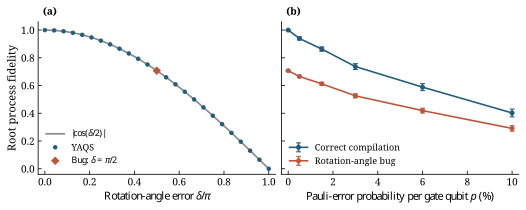

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "svg.fonttype": "none",
})
%config InlineBackend.figure_formats = ['svg']

colors = ["#225c80", "#bb563b"]
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), sharey=True, layout="constrained")
fine_angles = np.linspace(0, np.pi, 200)
axes[0].plot(fine_angles / np.pi, np.abs(np.cos(fine_angles / 2)), color="0.55", lw=1.7, label=r"$|\cos(\delta/2)|$")
axes[0].plot(angles / np.pi, angle_overlaps, "o", ms=3.5, color=colors[0], label="YAQS")
axes[0].plot(0.5, bug_result["fidelity"], "D", ms=5, color=colors[1], label=r"Bug: $\delta=\pi/2$")
axes[0].set(xlabel=r"Rotation-angle error $\delta/\pi$", ylabel="Root process fidelity", xlim=(-0.03, 1.03))
axes[0].legend(frameon=False, fontsize=9, loc="lower left")

for (label, results), color in zip(noise_results.items(), colors, strict=True):
    values = [result["fidelity"] for result in results]
    errors = [result["fidelity_error"] for result in results]
    axes[1].errorbar(100 * probabilities, values, yerr=errors, color=color, marker="o", ms=4, lw=1.6, capsize=2.5, label=label)
axes[1].set(xlabel=r"Pauli-error probability per gate qubit $p$ (%)", xlim=(-0.3, 10.3))
axes[1].legend(frameon=False, fontsize=9, loc="lower left")
for label, ax in zip(("(a)", "(b)"), axes, strict=True):
    ax.text(0.02, 1.03, label, transform=ax.transAxes, va="bottom", fontweight="bold")
    ax.set_ylim(-0.04, 1.06)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(top=False, right=False)
plt.show()

**Compiler errors and hardware noise reduce agreement in different ways.** (a)
The noiseless overlap follows the single-angle error formula. (b) With no noise,
the correct compilation agrees with the reference, while the faulty circuit
starts below one. As the Pauli-error probability increases, both estimates fall
in this example. Error bars show one Monte Carlo standard error from 256
trajectories. Lines join sampled points.

This comparison tells us whether compilation preserves the intended operation
and how a specified hardware model changes its process fidelity. It does not
identify an unknown bug or infer device noise from measurements. For learning
noise strengths from observed dynamics, see {doc}`digital_twin`.

For noisy results, `equivalent` applies the same overlap threshold to the point
estimate without using its error bar. Treat this as a sampled comparison, not an
exact noisy-channel certificate. In particular, a zero reported error bar when
every sampled overlap is zero does not establish zero uncertainty.

## Further options

### Accuracy and backends

Keep `representation="auto"` for automatic selection, or choose `"matrix"` or
`"mpo"` explicitly. Dense matrix storage grows as $4^n$; MPO cost depends on the
operator's bond dimensions and can also grow rapidly. The MPO method is
described in {footcite:p}`sander2025_EquivalenceChecking`.

The constructor's `fidelity` sets the decision threshold, while `threshold` sets
the MPO singular-value cutoff. These control different errors. For an
approximate comparison, choose a decision threshold that matches your purpose
and check that numerical truncation does not determine the answer. The returned
`representation` records which backend ran.

Terminal measurements are ignored for unitary checks; mid-circuit measurements
are unsupported. Decompose gates on more than two qubits before using the MPO
backend. See {ref}`circuit-custom-gates` for supported gate translation.

### Noise models and returned data

The checker supports stochastic Pauli errors, including Pauli products. It
rejects dissipative channels such as relaxation; use the simulator for those
channels. See {doc}`realistic_noise_models` for model construction.
Distribution-valued strengths are drawn once per `check`, then held fixed across
its trajectories. The resolved same-support probabilities must still sum to at
most one.

Pass `return_trajectories=True` to keep each trajectory result. Noisy results
have `matrix=None` and `mpo=None` because the ensemble is a channel. For MPO
checks, returned entropies and zero-padded Schmidt spectra are trajectory means,
not spectra of that channel. `fidelity_error` is `None` for a single trajectory.

### Inputs and execution

`check` accepts Qiskit circuits, OpenQASM file paths, and raw OpenQASM source
strings. OpenQASM 3 requires the optional `mqt-yaqs[qasm3]` extra. File paths
allow includes to resolve relative to the source file.

Parallel execution is enabled by default. `max_workers` caps concurrency, and
`mp_context` controls the start method for noisy process pools. A nonnegative
`random_seed` makes sampled trajectories reproducible across worker scheduling.
See {class}`~mqt.yaqs.EquivalenceChecker` for the full settings and returned
fields.

```{footbibliography}
```